# Deutschlandticket Adoption Potential: Synthetic Public Transport Commute Analysis

**Workplace:** Johnson & Johnson Medical GmbH, Robert-Koch-Straße 1, 22851 Norderstedt

synthetic data generation, public-transport connection assessment, door-to-door commute time, commute grouping, Deutschlandticket adoption scoring


## 1. Business Question
How attractive is public transport for synthetic employees commuting to the Norderstedt workplace, and which residential areas have the greatest potential for Deutschlandticket adoption?




In [45]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import folium
from folium.plugins import MarkerCluster

employees = pd.read_csv("synthetic_employees.csv")
stations = pd.read_csv("synthetic_stations.csv")
employees.head()


,employee_id,home_area,latitude,longitude,distance_to_workplace_km,walk_to_station_min,waiting_time_min,public_transport_min,transfer_count,station_to_work_min,door_to_door_min,commute_group,connectivity_score,adoption_score,adoption_category
0,EMP0001,Hamburg-Bergedorf,53.506588,10.190010,31.34,5.8,4.8,48.3,0,10.8,69.6,>60 min,49.2,45.4,Medium
1,EMP0002,Hamburg-Nord,53.616884,10.042067,2.82,4.9,7.4,26.7,1,11.3,54.3,46–60 min,57.1,55.7,Medium
2,EMP0003,Hamburg-Harburg,53.508831,10.019444,36.88,9.1,11.2,33.8,3,9.9,76.0,>60 min,24.7,25.7,Low
3,EMP0004,Hamburg-Wandsbek,53.570493,10.102187,17.62,7.7,7.9,44.1,2,9.1,76.7,>60 min,31.9,31.7,Low
4,EMP0005,Hamburg-Altona,53.595269,9.919978,12.59,8.0,7.3,39.4,1,9.0,67.6,>60 min,44.9,42.9,Medium


## 2. Data cleaning


In [34]:
print("Dataset shape:", employees.shape)
print("\nMissing values:")
print(employees.isna().sum())
print("\nDuplicate employee IDs:", employees.employee_id.duplicated().sum())


Dataset shape: (1000, 15)

Missing values:
employee_id                 0
home_area                   0
latitude                    0
longitude                   0
distance_to_workplace_km    0
walk_to_station_min         0
waiting_time_min            0
public_transport_min        0
transfer_count              0
station_to_work_min         0
door_to_door_min            0
commute_group               0
connectivity_score          0
adoption_score              0
adoption_category           0
dtype: int64

Duplicate employee IDs: 0


## 3. Door-to-Door Commute Method

Door-to-door time is modelled as:

walk to station + waiting + public transport + transfer penalty + final walk

The transfer penalty is 5 minutes per transfer as an assumption.


In [36]:
employees["recalculated_door_to_door_min"] = (
    employees.walk_to_station_min + employees.waiting_time_min +
    employees.public_transport_min + employees.transfer_count*5 +
    employees.station_to_work_min
).round(1)
print("Maximum calculation difference:",
      (employees.door_to_door_min-employees.recalculated_door_to_door_min).abs().max())


Maximum calculation difference: 3.1000000000000085


## 4. Commute-Time Groups


,employees,percentage
commute_group,,
≤30 min,5,0.5
31–45 min,94,9.4
46–60 min,370,37.0
>60 min,531,53.1


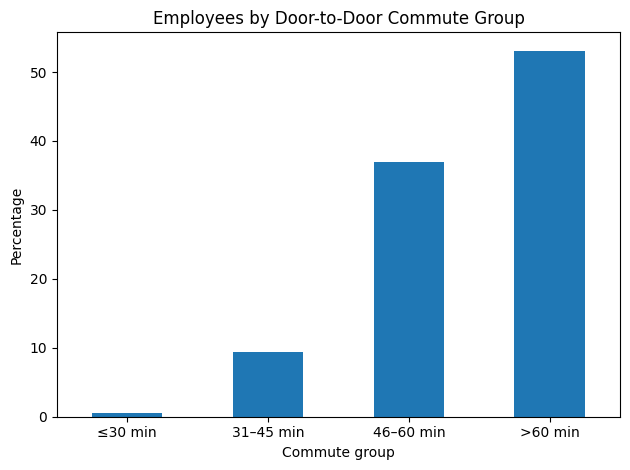

In [37]:
order=["≤30 min","31–45 min","46–60 min",">60 min"]
counts=employees.commute_group.value_counts().reindex(order,fill_value=0)
summary=pd.DataFrame({"employees":counts,"percentage":(counts/len(employees)*100).round(1)})
display(summary)

summary["percentage"].plot(kind="bar",title="Employees by Door-to-Door Commute Group")
plt.ylabel("Percentage")
plt.xlabel("Commute group")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Area Connectivity


In [38]:
area_summary=employees.groupby("home_area").agg(
    employees=("employee_id","count"),
    avg_commute_min=("door_to_door_min","mean"),
    avg_connectivity=("connectivity_score","mean"),
    avg_adoption_score=("adoption_score","mean")
).sort_values("avg_commute_min")
display(area_summary.round(1))


,employees,avg_commute_min,avg_connectivity,avg_adoption_score
home_area,,,,
Norderstedt,76,46.5,67.3,66.6
Hamburg-Nord,166,56.3,56.7,54.9
Hamburg-Eimsbüttel,169,58.2,52.9,51.6
Hamburg-Altona,233,59.2,54.6,52.6
Hamburg-Wandsbek,146,64.4,47.5,46.0
Pinneberg,23,66.0,47.2,46.0
Ahrensburg,27,70.6,44.6,43.3
Hamburg-Harburg,71,71.8,41.8,40.8
Hamburg-Bergedorf,89,73.2,42.0,40.2


# Door to Door commute by residential area

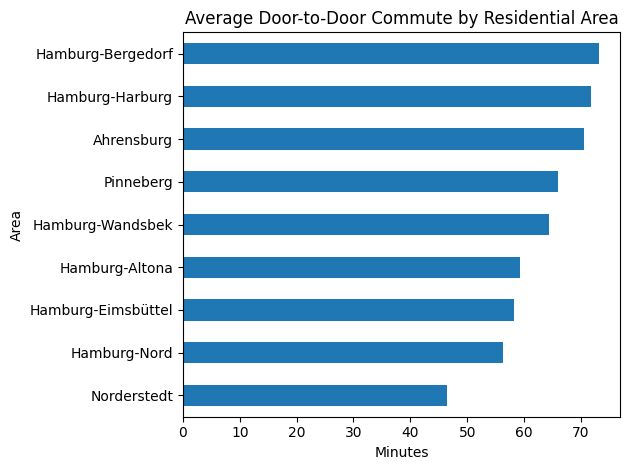

In [39]:
area_summary.avg_commute_min.sort_values().plot(kind="barh",
    title="Average Door-to-Door Commute by Residential Area")
plt.xlabel("Minutes")
plt.ylabel("Area")
plt.tight_layout()
plt.show()


## 6. Deutschlandticket Adoption Score

- 40% commute-time attractiveness
- 30% connectivity
- 20% walking convenience
- 10% transfer simplicity

Score bands: Low <40, Medium 40–69, High ≥70.


,employees,percentage
adoption_category,,
Low,248,24.8
Medium,652,65.2
High,100,10.0


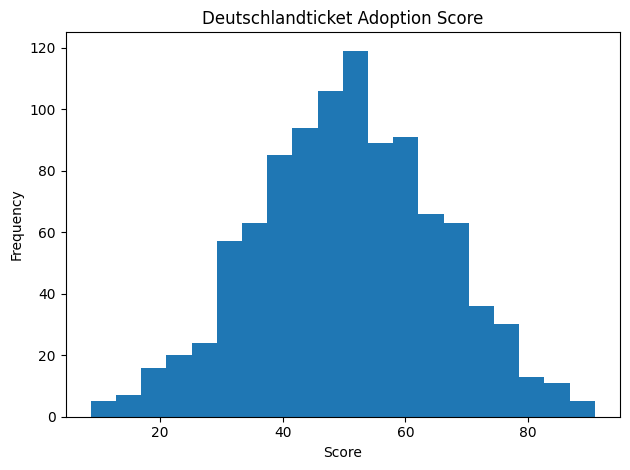

In [40]:
adoption_counts=employees.adoption_category.value_counts().reindex(["Low","Medium","High"],fill_value=0)
adoption_summary=pd.DataFrame({
    "employees":adoption_counts,
    "percentage":(adoption_counts/len(employees)*100).round(1)
})
display(adoption_summary)

employees.adoption_score.plot(kind="hist",bins=20,title="Deutschlandticket Adoption Score")
plt.xlabel("Score")
plt.tight_layout()
plt.show()


# 7 Linear regression commute time vs adoption score

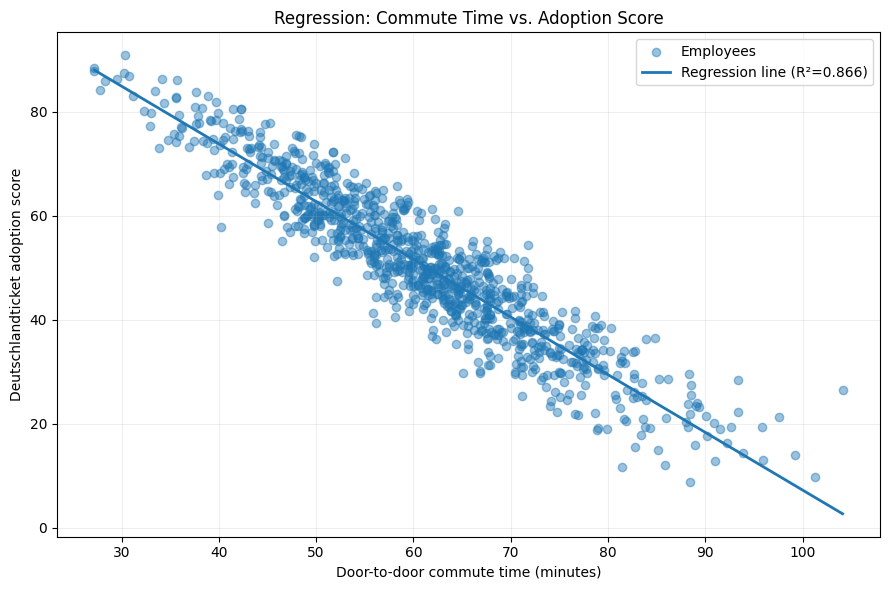

Regression equation: adoption_score = 118.27 + (-1.11 × door_to_door_min)
Pearson r = -0.931
p-value = 0
R² = 0.866


In [41]:


x = analysis_df["door_to_door_min"]
y = analysis_df["adoption_score"]

slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept

# R-squared
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r_squared = 1 - (ss_res / ss_tot)

r, p = pearsonr(x, y)

plt.figure(figsize=(9, 6))
plt.scatter(x, y, alpha=0.45, label="Employees")
order = np.argsort(x.values)
plt.plot(x.values[order], y_pred.values[order], linewidth=2,
         label=f"Regression line (R²={r_squared:.3f})")
plt.xlabel("Door-to-door commute time (minutes)")
plt.ylabel("Deutschlandticket adoption score")
plt.title("Regression: Commute Time vs. Adoption Score")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Regression equation: adoption_score = {intercept:.2f} + ({slope:.2f} × door_to_door_min)")
print(f"Pearson r = {r:.3f}")
print(f"p-value = {p:.4g}")
print(f"R² = {r_squared:.3f}")

## 8. Factors Influencing Adoption


In [16]:
factors=["door_to_door_min","connectivity_score","walk_to_station_min",
         "station_to_work_min","transfer_count","public_transport_min"]
display(employees[factors+["adoption_score"]].corr()["adoption_score"].sort_values(ascending=False).to_frame("correlation"))


,correlation
adoption_score,1.000000
connectivity_score,0.990863
walk_to_station_min,-0.424115
station_to_work_min,-0.431804
transfer_count,-0.574351
public_transport_min,-0.607655
door_to_door_min,-0.930824


# Pearson correlation Heat map

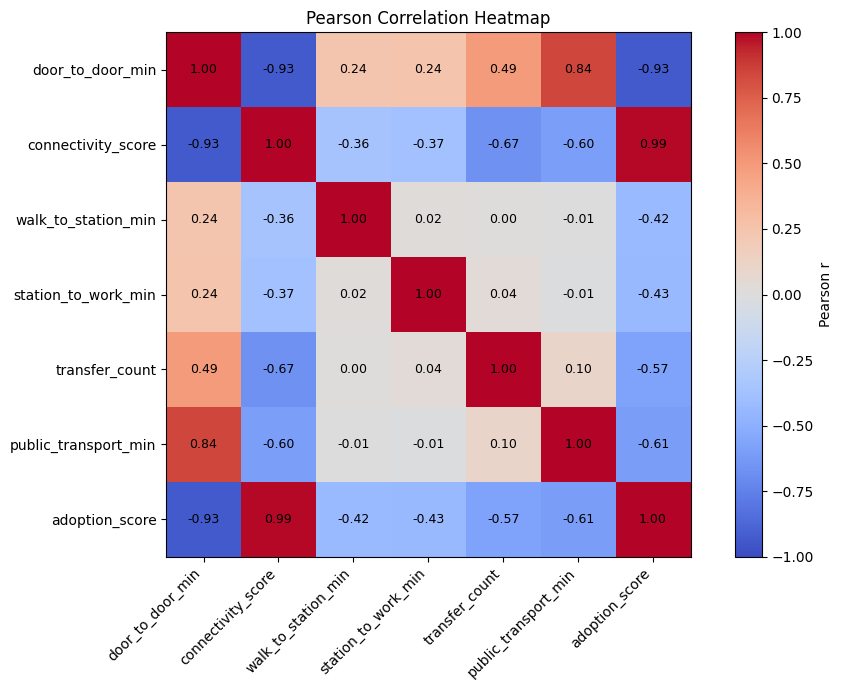

,variable,pearson_r,p_value,absolute_r
1,connectivity_score,0.9909,0.0,0.9909
0,door_to_door_min,-0.9308,0.0,0.9308
5,public_transport_min,-0.6077,0.0,0.6077
4,transfer_count,-0.5744,0.0,0.5744
3,station_to_work_min,-0.4318,0.0,0.4318
2,walk_to_station_min,-0.4241,0.0,0.4241


In [43]:
corr_vars = [
    "door_to_door_min", "connectivity_score", "walk_to_station_min",
    "station_to_work_min", "transfer_count", "public_transport_min",
    "adoption_score"
]
corr_vars = [c for c in corr_vars if c in analysis_df.columns]

corr_matrix = analysis_df[corr_vars].corr(method="pearson")

# Pearson correlation heatmap
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_vars)))
ax.set_yticks(range(len(corr_vars)))
ax.set_xticklabels(corr_vars, rotation=45, ha="right")
ax.set_yticklabels(corr_vars)
ax.set_title("Pearson Correlation Heatmap")

for i in range(len(corr_vars)):
    for j in range(len(corr_vars)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, label="Pearson r")
plt.tight_layout()
plt.show()

# Pearson correlation specifically with adoption score
pearson_rows = []
for col in corr_vars:
    if col != "adoption_score":
        r, p = pearsonr(analysis_df[col], analysis_df["adoption_score"])
        pearson_rows.append({
            "variable": col,
            "pearson_r": r,
            "p_value": p,
            "absolute_r": abs(r)
        })

pearson_results = pd.DataFrame(pearson_rows).sort_values("absolute_r", ascending=False)
display(pearson_results.round(4))

## 9. Strong and Weak Connectivity Areas


In [13]:
print("Strongest connectivity:")
display(area_summary.sort_values("avg_connectivity",ascending=False).head(5).round(1))

print("Lowest connectivity:")
display(area_summary.sort_values("avg_connectivity").head(5).round(1))


Strongest connectivity:


,employees,avg_commute_min,avg_connectivity,avg_adoption_score
home_area,,,,
Norderstedt,76,46.5,67.3,66.6
Hamburg-Nord,166,56.3,56.7,54.9
Hamburg-Altona,233,59.2,54.6,52.6
Hamburg-Eimsbüttel,169,58.2,52.9,51.6
Hamburg-Wandsbek,146,64.4,47.5,46.0


Lowest connectivity:


,employees,avg_commute_min,avg_connectivity,avg_adoption_score
home_area,,,,
Hamburg-Harburg,71,71.8,41.8,40.8
Hamburg-Bergedorf,89,73.2,42.0,40.2
Ahrensburg,27,70.6,44.6,43.3
Pinneberg,23,66.0,47.2,46.0
Hamburg-Wandsbek,146,64.4,47.5,46.0


## 10. Interactive Map

 Interactive map containing synthetic employee locations, the workplace, nearby HVV stations, commute-time clusters and high-potential users.


In [46]:


workplace=[53.7070,9.9940]  # analytical reference point for the specified workplace area
m=folium.Map(location=workplace,zoom_start=10)
folium.Marker(workplace,tooltip="Workplace analytical reference").add_to(m)
cluster=MarkerCluster(name="Synthetic employees").add_to(m)

for _,r in employees.sample(min(300,len(employees)),random_state=42).iterrows():
    folium.CircleMarker(
        [r.latitude,r.longitude],radius=3,
        popup=f"{r.employee_id} | {r.commute_group} | Adoption {r.adoption_score:.0f}"
    ).add_to(cluster)

for _,r in stations.iterrows():
    folium.Marker([r.latitude,r.longitude],tooltip=r.station_name).add_to(m)

folium.LayerControl().add_to(m)
m


## 11. Final Business Summary


In [15]:
within30=(employees.door_to_door_min<=30).mean()*100
within45=(employees.door_to_door_min<=45).mean()*100
within60=(employees.door_to_door_min<=60).mean()*100
over60=(employees.door_to_door_min>60).mean()*100
high=(employees.adoption_category=="High").mean()*100

print(f"Within 30 minutes: {within30:.1f}%")
print(f"Within 45 minutes: {within45:.1f}%")
print(f"Within 60 minutes: {within60:.1f}%")
print(f"Over 60 minutes: {over60:.1f}%")
print(f"High adoption potential: {high:.1f}%")
print(f"Average commute: {employees.door_to_door_min.mean():.1f} minutes")
print(f"Average adoption score: {employees.adoption_score.mean():.1f}/100")


Within 30 minutes: 0.5%
Within 45 minutes: 10.2%
Within 60 minutes: 47.1%
Over 60 minutes: 52.9%
High adoption potential: 10.0%
Average commute: 61.0 minutes
Average adoption score: 50.6/100


### conclusion

The most attractive target areas are those combining shorter door-to-door journeys, good connectivity, limited transfers and short walking segments. Areas with longer journeys and weaker connectivity represent lower immediate adoption potential but may benefit from targeted employer communication or first/last-mile improvements.

The visualizations help identify patterns, distributions, and possible outliers in the data, while the Pearson correlation analysis measures the strength and direction of relationships between numerical variables. The regression analysis further helps understand whether changes in one variable are associated with changes in another. Overall, combining descriptive statistics with correlation and regression provides a more complete understanding of the factors influencing Deutschlandticket usage and user behavior.
